# 2D Heat Equation with EvoKAN-SF

- PDE:
  $$
  \partial_t u = \alpha (u_{xx}+u_{yy}) + u(1-u), \qquad \Omega = (-1,1)^2
  $$
- IC:
  $$
  u(x,y,0)=\cos(\pi x)\cos(\pi y)
  $$
- BC:
  $$
  \frac{\partial u}{\partial n}=0
  $$
- Parameter:
  $\alpha = 0.1$
- Formulation:
  strong form


In [8]:
import torch
import numpy as np
import scipy

print(torch.__version__)
print(np.__version__)
print(scipy.__version__)

2.5.1+cu121
1.26.4
1.15.2


In [9]:
import cupy as cp
import cupyx.scipy.sparse.linalg

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import *

class SplineLinear(nn.Linear):
    def __init__(self, in_features: int, out_features: int, init_scale: float = 0.1, **kw) -> None:
        self.init_scale = init_scale
        super().__init__(in_features, out_features, bias=False, **kw)

    def reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.weight, mean=0, std=self.init_scale)

class RadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        self.grid = torch.linspace(grid_min, grid_max, num_grids)
        #self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) 

class FastKANLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = True,
        use_layernorm: bool = False,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim, bias=False)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y

In [11]:
class FirstRadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        self.grid = torch.linspace(grid_min, grid_max, num_grids)
        #self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) 

class FastKANFirstLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = False,
        use_layernorm: bool = False,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = FirstRadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y

In [12]:
class KAN(torch.nn.Module):
    def __init__(
        self,
        layers_hidden,
        grid_min: float = -1.,
        grid_max: float = 1.,
        num_grids: int = 8,
        use_base_update: bool = True,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ):
        super(KAN, self).__init__()
        self.layers = torch.nn.ModuleList()


        self.layers.append(
                FastKANFirstLayer(
                    input_dim = layers_hidden[0],
                    output_dim = layers_hidden[1],
                    grid_min=grid_min,
                    grid_max=grid_max,
                    num_grids=num_grids,
                    use_base_update=False,
                    base_activation=base_activation,
                    spline_weight_init_scale=spline_weight_init_scale,
                )
            )


        for in_features, out_features in zip(layers_hidden[1:], layers_hidden[2:]):
            self.layers.append(
                FastKANLayer(
                    in_features,
                    out_features,
                    grid_min=grid_min,
                    grid_max=grid_max,
                    num_grids=num_grids,
                    use_base_update=use_base_update,
                    base_activation=base_activation,
                    spline_weight_init_scale=spline_weight_init_scale,
                )
            )

    def forward(self, x1: torch.Tensor, x2: torch.Tensor, update_grid=False):
        y = torch.clone(torch.hstack((x1, x2)))
        for layer in self.layers:
            y = layer(y)
        return y

## Data Generation

- Domain:
  $\Omega = (-1,1)^2$
- Initial field:
  $u(x,y,0)=\cos(\pi x)\cos(\pi y)$
- Grid:
  `dense_points = 40`, `sparse_points = 0`
- Output:
  `grid_x`, `X1_init`, `X2_init`, `U_init`


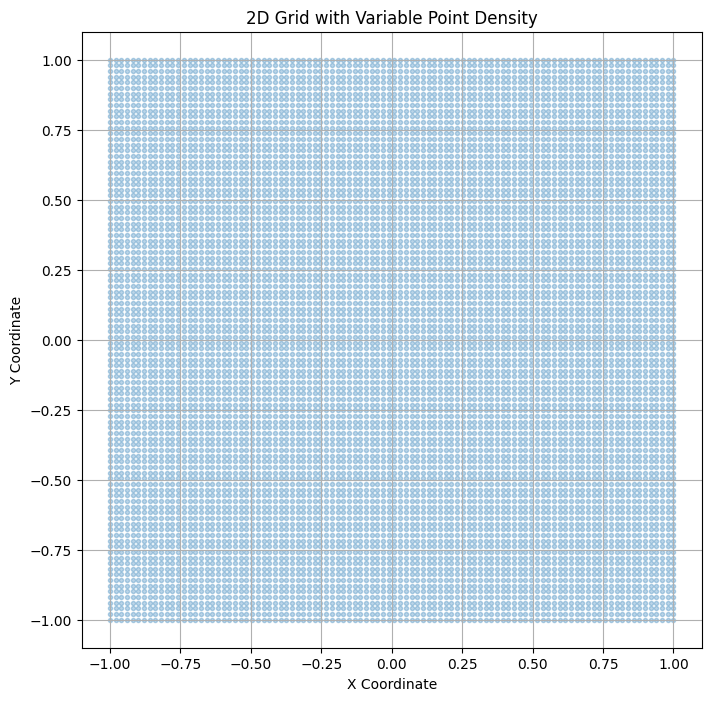

(10000, 2)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_2d_grid(dense_points, sparse_points):
    # Points in the dense region
    dense_segment = np.linspace(-1, 1, dense_points)

    # Points in the sparse regions
    sparse_segment1 = np.linspace(0.01, -0.1, sparse_points, endpoint=False)
    sparse_segment2 = np.linspace(0.1, 1, sparse_points, endpoint=False)

    # Combine segments
    x_values = np.concatenate([sparse_segment1, dense_segment, sparse_segment2])
    y_values = np.concatenate([sparse_segment1, dense_segment, sparse_segment2])

    # Create a mesh grid
    x_grid, y_grid = np.meshgrid(x_values, y_values)

    return x_grid.flatten(), y_grid.flatten()

# Set the number of points in each region
dense_points = 40  # More points in the dense interval
sparse_points = 0  # Fewer points in the sparse intervals
num_of_mesh = dense_points + sparse_points

# Generate the grid
x_samples, y_samples = generate_2d_grid(dense_points, sparse_points)

# Plot the results
plt.figure(figsize=(8, 8))
plt.scatter(x_samples, y_samples, alpha=0.3, marker='.')
plt.title('2D Grid with Variable Point Density')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

grid_x = np.column_stack((x_samples, y_samples))
print(grid_x.shape)

In [14]:
def initial_condition(x1, x2):
  u = np.cos(np.pi * x1) * np.cos(np.pi * x2)
  return u

In [15]:
num_of_x = grid_x.shape[0]
f = initial_condition(grid_x[:, 0], grid_x[:, 1])

print(f.shape)

(10000,)


In [16]:
X1_init = torch.tensor(grid_x[:, 0].reshape(-1,1), requires_grad=True).float()
X2_init = torch.tensor(grid_x[:, 1].reshape(-1,1), requires_grad=True).float()
U_init = torch.tensor(f.reshape(-1,1), requires_grad=True).float()

In [17]:
print(X1_init.shape)
print(X2_init.shape)
print(U_init.shape)

torch.Size([10000, 1])
torch.Size([10000, 1])
torch.Size([10000, 1])


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define model
model = KAN([2, 4, 4, 4, 1])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
print(device)
model.to(device)
# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
# Define loss
criterion = nn.MSELoss()

cpu


In [19]:
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Number of trainable parameters:", num_trainable_params)

Number of trainable parameters: 388


In [20]:
def train_step(model:torch.nn.Module,
               X1_init, X2_init, U_init,
               epoch,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device:torch.device=device):

  train_loss = 0

  # Put model into training mode
  model.train()

  # Put data on target device
  X1_init, X2_init= X1_init.to(device), X2_init.to(device)
  U_init= U_init.to(device)

  # 1. Forward pass
  u_init_pred = model(X1_init, X2_init)

  # 2. Calculate loss and metric
  loss_u_init = loss_fn(u_init_pred, U_init)

  loss = loss_u_init

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  # Print the loss
  train_loss = loss
  if epoch % 500 ==0:
    print(f"Train loss:{train_loss:.8f}")

In [21]:
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """Prints difference between start and end time."""
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [22]:
torch.manual_seed(42)

# Measure time
from tqdm.auto import tqdm
from timeit import default_timer as timer
start_time = timer()


# Set epochs
epochs = 20001

# Tarin the model
for epoch in tqdm(range(epochs)):
  if epoch % 500 == 0:
    print(f"Epoch:{epoch}\n----------")
  train_step(
      model = model,
      X1_init = X1_init, X2_init = X2_init,  U_init = U_init,
      epoch = epoch,
      loss_fn = criterion,
      optimizer = optimizer,
      device = device
  )

end_time = timer()
total_time = print_train_time(start = start_time, end = end_time, device = device)

  0%|          | 0/20001 [00:00<?, ?it/s]

Epoch:0
----------
Train loss:0.34455135
Epoch:500
----------
Train loss:0.00136783
Epoch:1000
----------
Train loss:0.00036497
Epoch:1500
----------
Train loss:0.00017383
Epoch:2000
----------
Train loss:0.00009780
Epoch:2500
----------
Train loss:0.00005959
Epoch:3000
----------
Train loss:0.00003979
Epoch:3500
----------
Train loss:0.00002926
Epoch:4000
----------
Train loss:0.00002325
Epoch:4500
----------
Train loss:0.00001938
Epoch:5000
----------
Train loss:0.00001692
Epoch:5500
----------
Train loss:0.00001461
Epoch:6000
----------
Train loss:0.00001307
Epoch:6500
----------
Train loss:0.00001331
Epoch:7000
----------
Train loss:0.00001048
Epoch:7500
----------
Train loss:0.00000934
Epoch:8000
----------
Train loss:0.00000847
Epoch:8500
----------
Train loss:0.00000784
Epoch:9000
----------
Train loss:0.00002046
Epoch:9500
----------
Train loss:0.00000645
Epoch:10000
----------
Train loss:0.00000590
Epoch:10500
----------
Train loss:0.00000546
Epoch:11000
----------
Train loss:

## Training Check

- Model:
  `KAN([2, 4, 4, 4, 1])`
- Optimizer:
  `AdamW`, `lr = 5e-4`, `weight_decay = 1e-4`
- Epochs:
  `20001`
- Check:
  initial-condition fit on the full grid


In [23]:
torch.manual_seed(42)
def eval_y(model: torch.nn.Module,
               X1, X2,
               loss_fn: torch.nn.Module,
               device = device):
  loss_res = 0
  model.eval()
  X1, X2 = X1.to(device), X2.to(device)
  y_pred = model(X1, X2)

  return y_pred

In [24]:
u_init_pred = eval_y(model = model,
                     X1 = X1_init, X2 = X2_init,
                     loss_fn = criterion,
                     device = device)

In [25]:
X_plot = np.linspace(0, 1, num_of_mesh)
Y_plot = np.linspace(0, 1, num_of_mesh)

X_plot_mesh, Y_plot_mesh = np.meshgrid(X_plot, Y_plot)

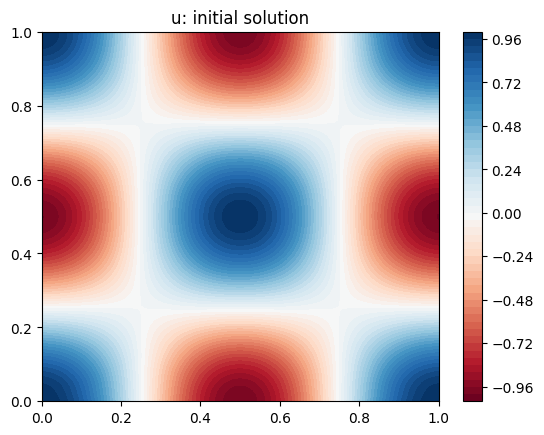

In [26]:
plt.contourf(X_plot_mesh, Y_plot_mesh, u_init_pred.to("cpu").detach().numpy().reshape(num_of_mesh, num_of_mesh), levels=50, cmap='RdBu')
plt.colorbar()
plt.title(f"u: initial solution")
plt.show()

In [27]:
import numpy as np

def calculate_boundary_gradients_mse(u, h):
    n = u.shape[0]  # Assuming u is a square matrix, n should be 101
    
    # Calculate gradients at boundaries using finite differences
    # Left boundary (first column)
    gradient_left = (u[:, 1] - u[:, 0]) / h
    
    # Right boundary (last column)
    gradient_right = (u[:, -1] - u[:, -2]) / h
    
    # Bottom boundary (first row)
    gradient_bottom = (u[1, :] - u[0, :]) / h
    
    # Top boundary (last row)
    gradient_top = (u[-1, :] - u[-2, :]) / h
    
    # Calculate the MSE for each boundary gradient
    mse_left = np.mean(gradient_left**2)
    mse_right = np.mean(gradient_right**2)
    mse_bottom = np.mean(gradient_bottom**2)
    mse_top = np.mean(gradient_top**2)

    return mse_left, mse_right, mse_bottom, mse_top


# Check Neumann boundary conditions
results = calculate_boundary_gradients_mse(u_init_pred.to("cpu").detach().numpy().reshape(num_of_mesh, num_of_mesh), h=2/num_of_mesh)
print("MSE of boundary gradients (Left, Right, Bottom, Top):", results)

MSE of boundary gradients (Left, Right, Bottom, Top): (0.017607797, 0.017608369, 0.08434317, 0.016301252)


## Parameter Derivatives

- Quantity:
  $$
  \frac{\partial u(x_i,y_i)}{\partial w}
  $$
- Tools:
  `functional_call`, `grad`, `vmap`
- Use:
  Jacobian assembly


In [28]:
from torch.func import functional_call, vmap, grad

def ft_compute_sample_grads(model, X1_init, X2_init):
    params = {k: v.detach() for k, v in model.named_parameters()}
    buffers = {k: v.detach() for k, v in model.named_buffers()}

    def predict(params, buffers, X1_init, X2_init):
        # prepend batch dimension for processing
        X1_init = X1_init.unsqueeze(0)
        X1_init = X1_init.to(device)

        X2_init = X2_init.unsqueeze(0)
        X2_init = X2_init.to(device)

        prediction = functional_call(model, (params, buffers), (X1_init, X2_init))

        return prediction.squeeze()

    ft_compute_grad = grad(predict)
    ft_compute_sample_grad = vmap(ft_compute_grad, in_dims=(None, None, 0, 0))
    ft_per_sample_grads = ft_compute_sample_grad(params, buffers, X1_init, X2_init)

    return ft_per_sample_grads

ft_per_sample_grads = ft_compute_sample_grads(model, X1_init, X2_init) # (n_layers, n_samples, out_dim, *)

In [29]:
print(len(ft_per_sample_grads))
print(ft_per_sample_grads.values)

7
<built-in method values of dict object at 0x79b0bab7a700>


In [30]:
print('num_layers: ', len(ft_per_sample_grads))
print('num_grads per sample: ', sum(g.shape[-2] * g.shape[-1] if len(g.shape) == 3 else g.shape[-1] for _, g in ft_per_sample_grads.items()))
# (n_layers, n_samples, out_dim, in_dim)
print(list(ft_per_sample_grads.values())[1].shape)

num_layers:  7
num_grads per sample:  388
torch.Size([10000, 4, 32])


## Jacobian Assembly

- Matrix:
  $$
  J = \frac{\partial u}{\partial w}
  $$
- Meaning:
  pointwise sensitivity of the field to parameter updates
- Use:
  strong-form least-squares step


In [31]:
W_origin = list(ft_per_sample_grads.values())
print(len(W_origin))
print(W_origin[0][0].shape)

7
torch.Size([4, 16])


In [32]:
def get_W_flatten(W_origin):
  W_flatten = []
  for i in range(len(W_origin)):
    W_flatten.append(torch.flatten(W_origin[i], start_dim=1))
  W_flatten_matrix = W_flatten[0]
  for i in range(1, len(W_origin)):
    W_flatten_matrix = torch.cat((W_flatten_matrix, W_flatten[i]), 1)
  return W_flatten_matrix

In [33]:
def compute_J():
  ft_per_sample_grads = ft_compute_sample_grads(model, X1_init, X2_init)
  W_origin = list(ft_per_sample_grads.values())
  J = get_W_flatten(W_origin)
  return J

In [34]:
J = compute_J()
print(J.shape)

torch.Size([10000, 388])


In [35]:
def change_to_np(list_vars):
  numpy_vars = []
  for i in range(len(list_vars)):
    numpy_vars.append(list_vars[i].cpu().detach().numpy())

  return numpy_vars

In [36]:
def store_parameter_size(list_vars):
  iter = len(list_vars)
  mat_size = []
  vec_size = []
  for i in range(iter):
    temp_vec = np.ndarray.flatten(list_vars[i], order='C')
    mat_size.append(list_vars[i].shape)
    vec_size.append(temp_vec.shape)
  return mat_size, vec_size

In [37]:
trainable_params = [param for param in model.parameters() if param.requires_grad]
np_vars = change_to_np(list(trainable_params))
mat_size, vec_size = store_parameter_size(np_vars)
print(mat_size)
print(vec_size)

[(4, 16), (4, 32), (4, 4), (4, 32), (4, 4), (1, 32), (1, 4)]
[(64,), (128,), (16,), (128,), (16,), (32,), (4,)]


In [38]:
def unfold_parameters(list_vars):
  mat_size, vec_size = store_parameter_size(list_vars)

  total_len = 0
  for i in range(len(vec_size)):
    total_len = total_len + vec_size[i][0]

  flat_vec = np.zeros(shape=(total_len,))
  iter = len(list_vars)
  index = 0
  for i in range(iter):
    end_index = index + vec_size[i][0]
    flat_vec[index:end_index] = np.ndarray.flatten(list_vars[i], order='C')
    index = index + vec_size[i][0]

  return flat_vec

In [39]:
def fold_vectors(vector, mat_size = mat_size, vec_size = vec_size):
  iter = len(mat_size)
  output_list = []
  index = 0
  for i in range(iter):
    end_index = index + vec_size[i][0]
    temp_mat = vector[index:end_index]
    output_list.append(np.reshape(temp_mat, newshape=mat_size[i], order='C'))
    index = index + vec_size[i][0]

  return output_list

In [40]:
flat_vec = unfold_parameters(np_vars)
print(len(flat_vec))
reconstruct_mat = fold_vectors(flat_vec, mat_size, vec_size)
print(len(reconstruct_mat))
print(reconstruct_mat[2].shape)

388
7
(4, 4)


## Spatial Derivatives

- Compute:
  $u$, $u_x$, $u_{xx}$, $u_y$, $u_{yy}$
- Method:
  autograd in $(x,y)$
- Use:
  residual, energy, boundary diagnostics


In [41]:
torch.manual_seed(42)
def Compute_gradient(model: torch.nn.Module,
                       X1, X2,
                       device = device):
  loss_res = 0
  model.eval()
  X1, X2 = X1.to(device), X2.to(device)

  # 1. Forward pass
  u_pred = model(X1, X2)

  # 2. Calculate loss and metric

  u_x = torch.autograd.grad(
      u_pred, X1,
      grad_outputs = torch.ones_like(u_pred),
      retain_graph = True,
      create_graph = True)[0]

  u_xx = torch.autograd.grad(
      u_x, X1,
      grad_outputs = torch.ones_like(u_x),
      retain_graph = True,
      create_graph = True)[0]

  u_y = torch.autograd.grad(
      u_pred, X2,
      grad_outputs = torch.ones_like(u_pred),
      retain_graph = True,
      create_graph = True)[0]

  u_yy = torch.autograd.grad(
      u_y, X2,
      grad_outputs = torch.ones_like(u_y),
      retain_graph = True,
      create_graph = True)[0]

  return u_pred, u_x, u_xx, u_y, u_yy

In [42]:
u, u_x, u_xx, u_y, u_yy = Compute_gradient(model, X1_init, X2_init)
u, u_x, u_xx, u_y, u_yy = u.to("cpu").detach().numpy(), u_x.to("cpu").detach().numpy(), u_xx.to("cpu").detach().numpy(), u_y.to("cpu").detach().numpy(), u_yy.to("cpu").detach().numpy()

## Compute $N$ and $E$

- Operator:
  $$
  N(u)=\alpha (u_{xx}+u_{yy}) + u(1-u)
  $$
- Constants:
  `vis = 0.1`, `lamb = 1`
- Marching:
  `delta_t = 1e-3`, `steps = 500`


In [43]:
def compute_N(u, u_x, u_y, u_xx, u_yy):
  vis = 0.1
  lamb = 1
  N = vis * (u_xx + u_yy) + lamb * u * (1 - u)
  return N

In [44]:
import numpy as np

def compute_boundary_derivatives_directly(J, h=2/(num_of_mesh)):
    n = num_of_mesh  # Number of points along each dimension

    # Calculate indices for boundaries
    left_indices = np.arange(0, n**2, n)
    right_indices = np.arange(n-1, n**2, n)
    bottom_indices = np.arange(0, n)
    top_indices = np.arange(n*(n-1), n**2)

    # Compute derivatives
    # u_x at x = -1 (left boundary)
    ux_left = (J[left_indices + 1] - J[left_indices]) / h

    # u_x at x = 1 (right boundary)
    ux_right = (J[right_indices] - J[right_indices - 1]) / h

    # u_y at y = -1 (bottom boundary)
    uy_bottom = (J[bottom_indices + n] - J[bottom_indices]) / h

    # u_y at y = 1 (top boundary)
    uy_top = (J[top_indices] - J[top_indices - n]) / h

    bc_left = np.vstack((ux_left, ux_right, uy_bottom, uy_top))

    return bc_left

In [45]:
def compute_N_bc(bc_left):
  N_1 = np.zeros(shape=(bc_left.shape[0] ,1))
  return N_1

In [46]:
def compute_E(u, u_x, u_y):
  E = 0.5*(u_x**2 + u_y**2)
  return E

In [47]:
def compute_r(energy, M, delta_t, previous_r):
  r = previous_r / (1 + delta_t*M/(2*energy))
  return r

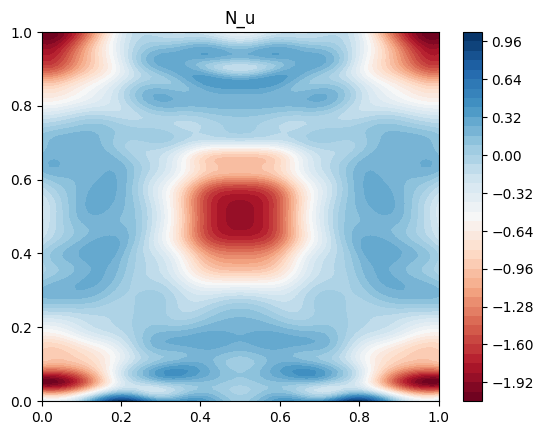

In [48]:
N = compute_N(u, u_x, u_y, u_xx, u_yy)

plt.contourf(X_plot, Y_plot, N.reshape(num_of_mesh, num_of_mesh), levels=50, cmap='RdBu')
plt.colorbar()
plt.title(f"N_u")
plt.show()

## Assign Parameters Back to the Model

- Input:
  flattened parameter update
- Steps:
  `fold_vectors(...)` -> `update_weights(...)`
- Purpose:
  restore layer-shaped tensors


In [49]:
def update_weights(new_vars):
  weights_tensor = []
  for i in range(len(new_vars)):
    weights_tensor.append(torch.tensor(new_vars[i]).float())

  trainable_params = [(name, param) for name, param in model.named_parameters() if param.requires_grad]
  for i, (name, param_tensor) in enumerate(trainable_params):
    model.state_dict()[name][:] = weights_tensor[i]

  '''
  for i, param_tensor in enumerate(model.state_dict()):
    model.state_dict()[param_tensor][:] = weights_tensor[i]
  '''

  return None

## Main Step

- Assemble:
  $J$, residual terms, boundary constraints
- Solve:
  least-squares update for parameters
- Return:
  updated weights, energy, BC errors, condition numbers, timing


In [ ]:
# =========================
# cell1 (revised)
# =========================
import cupy as cp
import cupyx.scipy.sparse.linalg
import scipy
import numpy as np
import time as _time


def one_step_ahead(t_start, delta_t, previous_r, step_idx, cond_every=10):
  # Compute w
  trainable_params = [param for param in model.parameters() if param.requires_grad]
  np_model_vars = change_to_np(list(trainable_params))
  mat_size, vec_size = store_parameter_size(np_model_vars)
  w = unfold_parameters(np_model_vars)

  # Compute J
  J = compute_J()
  J = J.to("cpu").detach().numpy().astype("float64")

  # Compute N
  u, u_x, u_xx, u_y, u_yy = Compute_gradient(model, X1_init, X2_init)
  u, u_x, u_xx, u_y, u_yy = (
      u.to("cpu").detach().numpy(),
      u_x.to("cpu").detach().numpy(),
      u_xx.to("cpu").detach().numpy(),
      u_y.to("cpu").detach().numpy(),
      u_yy.to("cpu").detach().numpy()
  )

  # Boundary gradient store
  mse_l, mse_r, mse_b, mse_t = calculate_boundary_gradients_mse(
      u.reshape(num_of_mesh, num_of_mesh), h=2/num_of_mesh
  )

  N = compute_N(u, u_x, u_y, u_xx, u_yy)

  # Deal with Neumann boundary condition
  bc_left = compute_boundary_derivatives_directly(J)
  N_bc = compute_N_bc(bc_left)

  # Combine them
  J = np.row_stack((J, bc_left))
  N = np.row_stack((N, N_bc))

  # Compute E and r
  E = compute_E(u, u_x, u_y)
  energy = np.sum(E)/len(E)
  M = np.reshape(N, newshape=(N.shape[0],))
  M = np.sum(M*M)/len(M)
  new_r = compute_r(energy, M, delta_t, previous_r)
  new_eta = new_r / max(np.sqrt(energy), 1e-12)

  # Solve for dw_dt
  right_side = N
  lsmr_result = scipy.sparse.linalg.lsmr(J, right_side)
  dw_dt = lsmr_result[0]
  lsmr_itn = int(lsmr_result[2])

  # Compute cond(A) every cond_every steps only
  cond_A = np.nan
  if (step_idx % cond_every) == 0:
      S = np.linalg.svd(J, compute_uv=False)
      cond_A = (S[0] / S[-1]) if (S.size > 0 and S[-1] > 0) else np.inf

  # Update
  new_w = w + delta_t*dw_dt
  new_vars = fold_vectors(new_w)
  update_weights(new_vars)

  return new_w, new_r, new_eta, energy, mse_l, mse_r, mse_b, mse_t, cond_A, lsmr_itn


In [51]:
E_0 = compute_E(u, u_x, u_y)
energy_0 = np.sum(E_0)/len(E_0)
r_0 = np.sqrt(energy_0)
print(r_0)

1.5710250559944932


In [ ]:
# =========================
# cell2 (revised)
# =========================
t_start = 0.0
delta_t = 1e-3
steps = 500

r_list = [r_0]
energy = []
time = []
coefficient_list = []
lsmr_iterations = []

mse_left = []
mse_right = []
mse_bottom = []
mse_top = []

# Store the condition number
condition_number = []

# wall clock time
loop_start = _time.perf_counter()

for i in range(steps):
  if i % 100 == 0:
    print(i)

  new_w, new_r, new_eta, new_energy, mse_l, mse_r, mse_b, mse_t, cond_A, lsmr_itn = one_step_ahead(
      t_start, delta_t, r_list[i], step_idx=i, cond_every=10
  )

  if (new_eta < 0.98) or (new_eta > 1.02):
    # Keep the original logic; use new_energy because energy has not been appended yet
    new_r = np.sqrt(max(new_energy, 0.0))

  t_start = t_start + delta_t
  time.append(t_start)
  r_list.append(new_r)
  coefficient_list.append(new_w)
  energy.append(new_energy)
  lsmr_iterations.append(lsmr_itn)

  # boundary gradient mse store
  mse_left.append(mse_l)
  mse_right.append(mse_r)
  mse_bottom.append(mse_b)
  mse_top.append(mse_t)

  # Store cond values; skipped steps keep NaN
  condition_number.append(cond_A)

final_t = t_start
loop_end = _time.perf_counter()

print(final_t)
print(f"Total wall clock time (loop): {loop_end - loop_start:.6f} s")

# Optionally inspect only computed condition numbers
cond_arr = np.asarray(condition_number, dtype=float)
valid = np.isfinite(cond_arr)
print("cond(A) samples (computed only):", cond_arr[valid][:10])
print("LSMR iteration samples:", lsmr_iterations[:10])
print(f"LSMR maxiter used: {lsmr_maxiter}")


0
100
200
300
400
0.5000000000000003
Total wall clock time (loop): 244.073283 s
cond(A) samples (computed only): [1.63711452e+17 7.66495444e+17 2.08429535e+18 1.68652568e+18
 1.09687368e+18 7.94938974e+17 6.19581851e+17 5.30443130e+17
 4.79263024e+17 4.30235937e+17]
LSMR iteration samples: [1808, 1852, 1919, 1975, 1955, 1966, 1948, 1912, 1880, 1873]
LSMR maxiter used: 2000


In [53]:
cond_arr = np.asarray(condition_number, dtype=float)
cond_mean = np.nanmean(cond_arr)   # NaNs are ignored automatically
print(f"Mean cond(A): {cond_mean:.4e}")

Mean cond(A): 6.9362e+17


In [54]:
test_u, test_u_x, test_u_xx, test_u_y, test_u_yy = Compute_gradient(model, X1_init, X2_init)

In [55]:
velocity_u = test_u.to("cpu").detach().numpy()

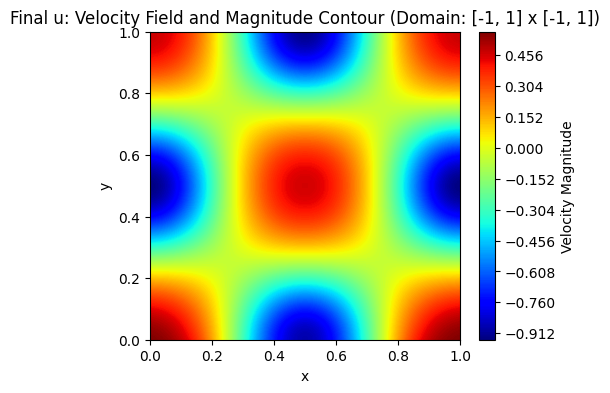

In [56]:
# Plotting the combined contour and quiver plot for the new domain
plt.figure(figsize=(5, 4))

# Contour plot of the velocity magnitude
plt.contourf(X_plot_mesh, Y_plot_mesh, velocity_u.reshape(num_of_mesh, num_of_mesh), levels=500, cmap='jet')
plt.colorbar(label='Velocity Magnitude')

# Titles and labels
plt.title('Final u: Velocity Field and Magnitude Contour (Domain: [-1, 1] x [-1, 1])')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

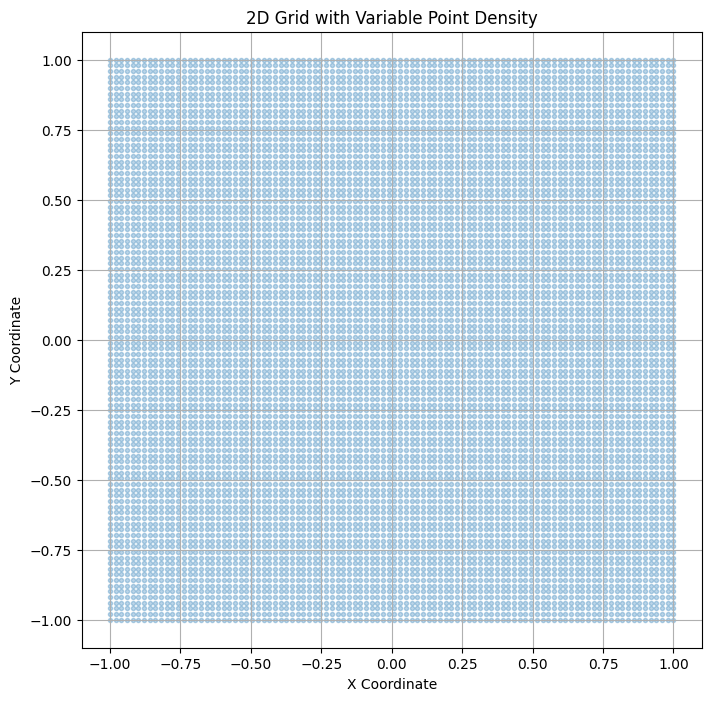

(10000, 2)


In [57]:
import numpy as np
import matplotlib.pyplot as plt

def generate_2d_grid(dense_points, sparse_points):
    # Points in the dense region
    dense_segment = np.linspace(-1, 1, dense_points)

    # Points in the sparse regions
    sparse_segment1 = np.linspace(0.01, -0.1, sparse_points, endpoint=False)
    sparse_segment2 = np.linspace(0.1, 1, sparse_points, endpoint=False)

    # Combine segments
    x_values = np.concatenate([sparse_segment1, dense_segment, sparse_segment2])
    y_values = np.concatenate([sparse_segment1, dense_segment, sparse_segment2])

    # Create a mesh grid
    x_grid, y_grid = np.meshgrid(x_values, y_values)

    return x_grid.flatten(), y_grid.flatten()

# Set the number of points in each region
dense_points = 100  # More points in the dense interval
sparse_points = 0  # Fewer points in the sparse intervals
num_of_mesh = dense_points + sparse_points

# Generate the grid
x_samples, y_samples = generate_2d_grid(dense_points, sparse_points)

# Plot the results
plt.figure(figsize=(8, 8))
plt.scatter(x_samples, y_samples, alpha=0.3, marker='.')
plt.title('2D Grid with Variable Point Density')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

grid_x = np.column_stack((x_samples, y_samples))
print(grid_x.shape)

X1_init = torch.tensor(grid_x[:, 0].reshape(-1,1), requires_grad=True).float()
X2_init = torch.tensor(grid_x[:, 1].reshape(-1,1), requires_grad=True).float()

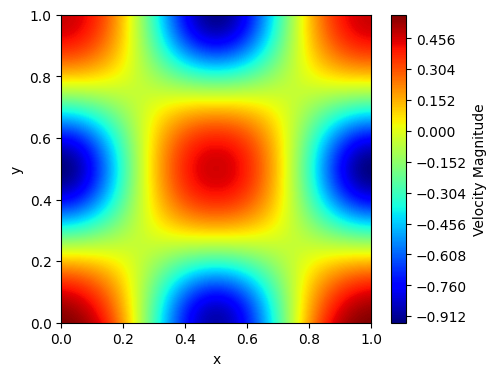

In [58]:
test_u, test_u_x, test_u_xx, test_u_y, test_u_yy = Compute_gradient(model, X1_init, X2_init)
velocity_u = test_u.to("cpu").detach().numpy()
# Plotting the combined contour and quiver plot for the new domain
plt.figure(figsize=(5, 4))

X_plot = np.linspace(0, 1, num_of_mesh)
Y_plot = np.linspace(0, 1, num_of_mesh)

X_plot_mesh, Y_plot_mesh = np.meshgrid(X_plot, Y_plot)

# Contour plot of the velocity magnitude
plt.contourf(X_plot_mesh, Y_plot_mesh, velocity_u.reshape(num_of_mesh, num_of_mesh), levels=500, cmap='jet')
plt.colorbar(label='Velocity Magnitude')

# Titles and labels
# plt.title('Final u: Velocity Field and Magnitude Contour (Domain: [-1, 1] x [-1, 1])')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

In [ ]:
import os
import numpy as np
import torch

# 1) Create the output directory
save_dir = "2D_Heat_EvoKAN_SF"
os.makedirs(save_dir, exist_ok=True)

# 2) Select output times (0.0, 0.1, ..., 0.7)
# time_targets = np.arange(0.0, 0.75, 0.01)
time_targets = np.arange(0.0, 0.50 + 1e-8, 0.01)
time_array = np.array(time)  # stored time history from the simulation
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]

# 3) Flatten coordinates used by Compute_gradient
x1_flat = X1_init.flatten()
x2_flat = X2_init.flatten()

# Domain boundary values computed after NumPy conversion
x1_np = x1_flat.detach().cpu().numpy()
x2_np = x2_flat.detach().cpu().numpy()
xmin, xmax = x1_np.min(), x1_np.max()
ymin, ymax = x2_np.min(), x2_np.max()

# 4) Accumulate boundary-gradient results
boundary_grads = []

for T, idx in zip(time_targets, indices_to_update):
    # 4.1) Update model parameters
    update_weights(fold_vectors(coefficient_list[idx]))
    
    # 4.2) Evaluate the solution and gradients (torch.Tensor)
    test_u, test_u_x, _, test_u_y, _ = Compute_gradient(model, X1_init, X2_init)
    
    # 4.3) Convert GPU tensors to NumPy arrays and flatten
    u_np  = test_u .detach().cpu().numpy().flatten()
    ux_np = test_u_x.detach().cpu().numpy().flatten()
    uy_np = test_u_y.detach().cpu().numpy().flatten()
    
    # 4.4) Save three-column (x, y, u) data
    sol_data = np.column_stack([x1_np, x2_np, u_np])
    sol_fname = os.path.join(save_dir, f"solution_t_{T:.2f}.txt")
    np.savetxt(
        sol_fname,
        sol_data,
        header="x y u",
        comments="",
        fmt="%.6f"
    )
    
    # 4.5) Compute boundary masks and mean gradients in NumPy
    mask_left  = np.isclose(x1_np, xmin)
    mask_right = np.isclose(x1_np, xmax)
    mask_lower = np.isclose(x2_np, ymin)
    mask_upper = np.isclose(x2_np, ymax)

    grad_left_mean   = ux_np[mask_left ].mean()
    grad_right_mean  = ux_np[mask_right].mean()
    grad_lower_mean  = uy_np[mask_lower].mean()
    grad_upper_mean  = uy_np[mask_upper].mean()
    
    boundary_grads.append([
        T,
        grad_left_mean,
        grad_right_mean,
        grad_upper_mean,
        grad_lower_mean,
    ])
    print(f"[t={T:.2f}] solution & grads saved")
    
# 5) Save all boundary-gradient statistics
boundary_grads = np.array(boundary_grads)
grad_fname = os.path.join(save_dir, "boundary_gradients.txt")
np.savetxt(
    grad_fname,
    boundary_grads,
    header="t grad_left grad_right grad_upper grad_lower",
    comments="",
    fmt="%.6f"
)
print(f"[Done] Saved to '{grad_fname}'.")


In [ ]:
import os

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

if 'lsmr_iterations' not in globals():
    raise NameError('lsmr_iterations is missing. Re-run the time-stepping cell first.')

lsmr_iters = np.asarray(lsmr_iterations, dtype=float).reshape(-1)
time_arr = np.asarray(time, dtype=float).reshape(-1)

if lsmr_iters.size == 0:
    raise ValueError('lsmr_iterations is empty. Time-stepping results are required.')

if time_arr.size != lsmr_iters.size:
    raise ValueError(f'time length ({time_arr.size}) does not match lsmr_iterations length ({lsmr_iters.size}).')

step_arr = np.arange(1, len(lsmr_iters) + 1)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharey=True)

axes[0].plot(step_arr, lsmr_iters, marker='o', markersize=3, linewidth=1)
axes[0].set_xlabel('Time step index')
axes[0].set_ylabel('LSMR iterations')
axes[0].set_title('Strong Form: LSMR Iteration Count')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_arr, lsmr_iters, marker='o', markersize=3, linewidth=1, color='tab:red')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('LSMR iterations')
axes[1].grid(True, alpha=0.3)

save_dir = os.path.join(os.getcwd(), '2D_Heat_EvoKAN_SF', 'lsmr_diagnostics')
os.makedirs(save_dir, exist_ok=True)
fig_path = os.path.join(save_dir, 'strong_lsmr_iteration_count.png')
mat_path = os.path.join(save_dir, 'EvoKAN_strong_lsmr_iterations.mat')

plt.tight_layout()
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

sio.savemat(
    mat_path,
    {
        'step': step_arr.reshape(-1, 1),
        'time': time_arr.reshape(-1, 1),
        'lsmr_iterations': lsmr_iters.reshape(-1, 1),
    }
)

print(f'cwd: {os.getcwd()}')
print(f'Saved figure to: {fig_path}')
print(f'Figure exists: {os.path.exists(fig_path)}')
print(f'Saved LSMR iteration history to: {mat_path}')
print(f'MAT exists: {os.path.exists(mat_path)}')
print(f'LSMR maxiter used: {lsmr_maxiter}')
